In [ ]:
!pip install rasterio -q

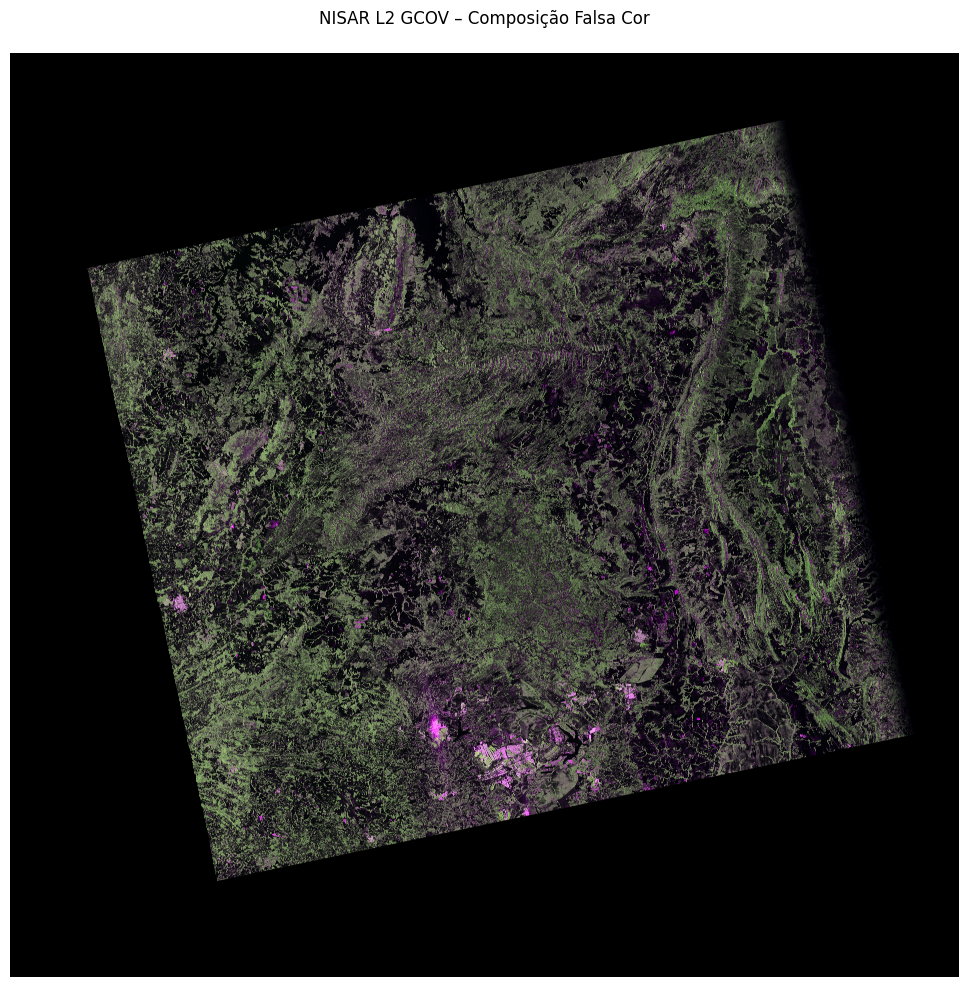

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

arquivo = "/content/drive/MyDrive/Dados_PDI/Cópia de NISAR_L2_PR_GCOV_027_146_A_170_4005_DHDH_A_20260811T090124_frequencyA_HHHV.tif"


# =========================================================
# Função de normalização
# =========================================================

def normalizar(img, mascara, pmin=2, pmax=98):

    valores = img[mascara]

    vmin, vmax = np.percentile(
        valores,
        [pmin, pmax]
    )


    resultado = np.zeros_like(img, dtype=np.float32)

    resultado[mascara] = (
        (img[mascara] - vmin) /
        (vmax - vmin)
    )

    resultado = np.clip(resultado, 0, 1)

    return resultado


# =========================================================
# Ler imagem em resolução
# =========================================================

with rasterio.open(arquivo) as src:

    fator = 1

    altura = src.height // fator
    largura = src.width // fator

    dados = src.read(
        [1, 2],
        out_shape=(2, altura, largura),
        resampling=Resampling.average
    ).astype("float32")


HH = dados[0]
HV = dados[1]


# =========================================================
# Tratar NaN / Inf
# =========================================================

HH[~np.isfinite(HH)] = np.nan
HV[~np.isfinite(HV)] = np.nan


# =========================================================
# Máscara de pixels válidos
# =========================================================

mascara = (
    np.isfinite(HH) &
    np.isfinite(HV) &
    (HH > 0) &
    (HV > 0)
)


# =========================================================
# Converter HH e HV para dB
# =========================================================

HH_db = np.full_like(HH, np.nan)
HV_db = np.full_like(HV, np.nan)

HH_db[mascara] = 10 * np.log10(HH[mascara])
HV_db[mascara] = 10 * np.log10(HV[mascara])

HH_db[mascara] = HH[mascara]
HV_db[mascara] = HV[mascara]
# =========================================================
# Calcular HH/HV em dB
#
# HH/HV em dB é equivalente a:
#
# 10 log10(HH/HV)
# = HH_dB - HV_dB
# =========================================================

HH_HV_db = np.full_like(HH, np.nan)

HH_HV_db[mascara] = (
    HH_db[mascara] -
    HV_db[mascara]
)


# =========================================================
# Normalização
# =========================================================

R = normalizar(
    HH_db,
    mascara,
    pmin=2,
    pmax=98
)

G = normalizar(
    HV_db,
    mascara,
    pmin=2,
    pmax=98
)

B = normalizar(
    HH_HV_db,
    mascara,
    pmin=2,
    pmax=98
)


# =========================================================
# RGB
# =========================================================

rgb = np.dstack([
    R,
    G,
    B
])


# =========================================================
# Colocar pixels inválidos em preto
# =========================================================

rgb[~mascara] = 0


# =========================================================
# Visualização
# =========================================================

plt.figure(figsize=(16, 12))

plt.imshow(rgb)

plt.axis("off")

plt.title(
    "NISAR L2 GCOV – Composição Falsa Cor\n"
)
plt.show()